# Analyze GNSS Continuous

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

In [3]:
def lt_fit_function(t, A, phi, B, C):
    return A * np.sin(2*np.pi*1/365.25 * t + phi) + B * t + C

In [4]:
# read in GNSS
pea1 = pd.read_csv('/Volumes/ProjectsGarlockCSAF/CSAF_Lidar/OtherDisplacements/PEA1.cwu.nam14.csv',skiprows=11)
pea2 = pd.read_csv('/Volumes/ProjectsGarlockCSAF/CSAF_Lidar/OtherDisplacements/PEA2.cwu.nam14.csv',skiprows=11)

In [5]:
pea1.columns

Index(['Date', ' North (mm)', ' East (mm)', ' Vertical (mm)',
       ' North Std. Deviation (mm)', ' East Std. Deviation (mm)',
       ' Vertical Std. Deviation (mm)', ' Quality', 'Unnamed: 8'],
      dtype='str')

A, phi, trend, offset [ 1.98653634 -0.78476366  0.03502749  2.01091113]
A, phi, trend, offset [-1.29147819  1.88937865 -0.02968075  2.41401499]


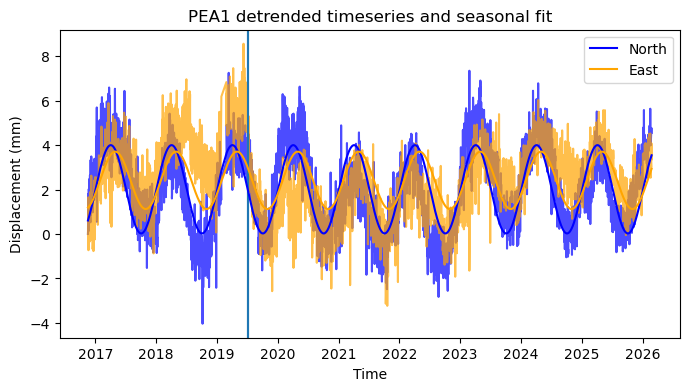

A, phi, trend, offset [ 0.45481388 -0.14943375  0.08956092  1.52722865]
A, phi, trend, offset [ -0.37011823 -10.40344968  -0.07673048  -1.24830447]


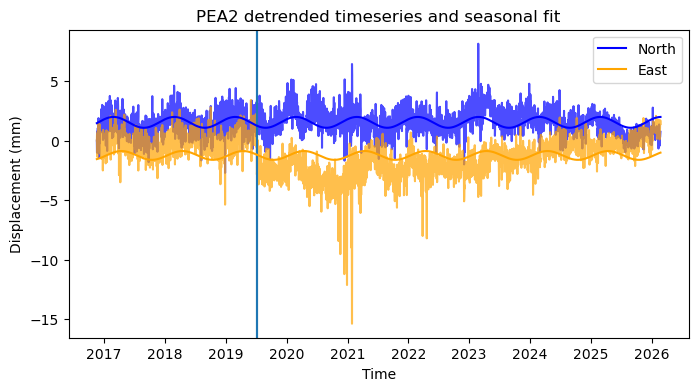

In [6]:
# What is the maximum possible seasonal difference?
fits = []
for tdf, name in zip([pea1,pea2],['PEA1','PEA2']):
    plt.figure(figsize=(8,4))
    for dir, c, label in zip([' North (mm)',' East (mm)'],['blue','orange'],['North','East']):
        t = np.array([pd.to_datetime(tdf.Date[i]).to_julian_date() - pd.to_datetime(tdf.Date[0]).to_julian_date() for i in range(len(tdf))])
        y_data = tdf[dir] 
        initial_guess = [0,0,0,0]
        fitted_params, pcov = curve_fit(lt_fit_function, t, y_data)

        # Extract the fitted parameters
        fit_A, fit_phi, fit_B, fit_C = fitted_params
        print('A, phi, trend, offset', fitted_params)
        fits.append(fit_A)
        y_fit = lt_fit_function(t,fit_A, fit_phi, fit_B, fit_C) 
        
        plt.plot(pd.to_datetime(tdf.Date), y_fit- fit_B * t, zorder=6,c=c,label=label)
        plt.plot(pd.to_datetime(tdf.Date), y_data- fit_B * t,c=c,alpha=0.7)
        plt.axvline(pd.to_datetime('2019-07-06'))
    plt.title(f'{name} detrended timeseries and seasonal fit')
    plt.xlabel('Time')
    plt.ylabel('Displacement (mm)')
    plt.legend()
    plt.show()

p1A_north, p1A_east, p2A_north, p2A_east = fits[0], fits[1], fits[2], fits[3]

p1 amp: 11.228485078170799
p2 amp: 0.687686334864068


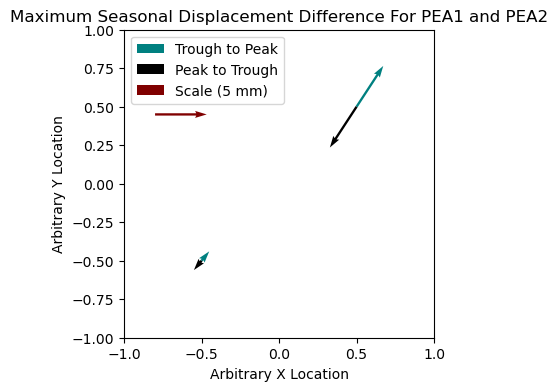

In [8]:

# Compute differences
p1dE = 2*np.absolute(p1A_east)
p1dN = 2*np.absolute(p1A_north)
p2dE = 2*np.absolute(p2A_east)
p2dN = 2*np.absolute(p2A_north)

print('p1 amp:',(p1dE**2+p1dN**2)**1/2)
print('p2 amp:',(p2dE**2+p2dN**2)**1/2)

plt.figure(figsize=(4,4))

plt.quiver(0.5,0.5, p1dE, p1dN,angles="xy",scale_units="xy",scale=15,color='teal',label='Trough to Peak')
plt.quiver(0.5,0.5, -1*p1dE, -1*p1dN,angles="xy",scale_units="xy",scale=15,label='Peak to Trough')

plt.quiver(-0.5,-0.5, p2dE, p2dN,angles="xy",scale_units="xy",scale=15,color='teal')
plt.quiver(-0.5,-0.5, -1*p2dE, -1*p2dN,angles="xy",scale_units="xy",scale=15)

plt.quiver(-0.8,0.45, 5, 0,angles="xy",scale_units="xy",scale=15,label='Scale (5 mm)',color='maroon')

plt.xlabel("Arbitrary X Location")
plt.ylabel("Arbitrary Y Location")
#plt.ylabel("Latitude")
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.legend(loc='upper left')
plt.title("Maximum Seasonal Displacement Difference For PEA1 and PEA2")
plt.show()